In [2]:


import jax 
import jax.numpy as jnp
import jax.random as jrandom


import haiku as hk
import optax

import matplotlib.pyplot as plt

from probjax.nn.transformers import Transformer
from probjax.nn.tokenizer import scalarize, ScalarTokenizer
from probjax.nn.helpers import GaussianFourierEmbedding
from probjax.nn.loss_fn import denoising_score_matching_loss

from probjax.distributions.sde import VPSDE, BaseSDE
from probjax.distributions import Normal, Independent
from probjax.distributions.transformed_distribution import TransformedDistribution
from probjax.distributions.discrete import Empirical

from probjax.utils.sdeint import sdeint
from probjax.utils.odeint import _odeint

from functools import partial




I0000 00:00:1702296866.653655  243725 tfrt_cpu_pjrt_client.cc:349] TfrtCpuClient created.
2023-12-11 13:14:31.082596: W external/xla/xla/service/gpu/nvptx_compiler.cc:708] The NVIDIA driver's CUDA version is 11.7 which is older than the ptxas CUDA version (11.8.89). Because the driver is older than the ptxas version, XLA is disabling parallel compilation, which may slow down compilation. You should update your NVIDIA driver or use the NVIDIA-provided CUDA forward compatibility packages.


In [3]:
cpu = jax.devices("cpu")[0]
jax.devices()

[gpu(id=0), gpu(id=1), gpu(id=2), gpu(id=3)]

In [4]:
ts = jnp.linspace(0, 3, 100)

def drift_lotka_volterra(t, data, alpha,beta, gamma, delta):
    predator, prey = data
    d_predator = alpha * predator - beta * predator * prey
    d_prey = -gamma * prey + delta * predator * prey
    return d_predator, d_prey

num_timeponts = 48
max_num_nodes = 4 + 2*num_timeponts
time_start = 0
time_end = 20
ts_dense = jnp.linspace(time_start, time_end, 500)


def generate_dense_data(key, n):
    key1, key2, key3, key4, key5, key6 = jrandom.split(key, 6)

    theta1 = jax.nn.sigmoid(jrandom.normal(key1, (n,1)))*2 + 1.
    theta2 = jax.nn.sigmoid(jrandom.normal(key2, (n,1)))*2 + 1.
    theta3 = jax.nn.sigmoid(jrandom.normal(key3, (n,1)))*2 + 1.
    theta4 = jax.nn.sigmoid(jrandom.normal(key4, (n,1)))*2 + 1.
    
    predator, prey = jax.vmap(lambda *args: _odeint(*args), in_axes=(None, None, None, 0,0,0,0))(drift_lotka_volterra, (1., 0.5), ts_dense, theta1, theta2, theta3, theta4)
    thetas = jnp.concatenate([theta1, theta2, theta3, theta4], axis=-1)
    return thetas, predator, prey


#with jax.default_device(cpu):
thetas, predator, prey = generate_dense_data(jrandom.PRNGKey(0), 100000)


In [5]:
def subsample_data(key, batch_size, thetas, predator, prey):
    key_batch, key_t,key_t2, key5, key6 = jrandom.split(key, 5)
    thetas = jrandom.choice(key_batch, thetas, (batch_size,), replace=False)
    predator = jrandom.choice(key_batch, predator, (batch_size,), replace=False)
    prey = jrandom.choice(key_batch, prey, (batch_size,), replace=False)
    
    n = thetas.shape[0]
    # Random time points 
    ts1 = jrandom.uniform(key_t, (n , num_timeponts), minval=time_start, maxval=time_end)
    ts2 = jrandom.uniform(key_t2, (n , num_timeponts), minval=time_start, maxval=time_end)
    predator = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts1, ts_dense, predator)
    prey = jax.vmap(lambda *args: jnp.interp(*args), in_axes=(0, None, 0))(ts2, ts_dense, prey)

    predator = predator + jrandom.normal(key5, predator.shape) * 0.001
    prey = prey + jrandom.normal(key6, prey.shape) * 0.001

    node_ids = jnp.array([0, 1, 2, 3] + [4] * num_timeponts + [5] * num_timeponts)
    node_metadata = jnp.concatenate([jnp.full((n, 4), jnp.nan),ts1, ts2], axis=1).reshape((n, -1, 1))
    full_data = jnp.concatenate([thetas, predator, prey], axis=1).reshape((n, -1, 1))
    return full_data, node_ids, node_metadata

sampler = partial(subsample_data, thetas=thetas, predator=predator, prey=prey)

In [6]:


def transformer_model(num_nodes, dim = 90, condition_token_dim=10, num_heads=8, num_layers=8, attn_size=5, widening_factor=4, output_scale_fn=None):
    
    if output_scale_fn is None:
        output_scale_fn = lambda t, x: x
    
    def model(t,data, data_id,meta_data, condition_mask):
        batch_size, current_nodes, _ = data.shape
        data_id = data_id.reshape(-1,current_nodes)
        condition_mask = condition_mask.reshape(-1,current_nodes)
        

        tokenizer = ScalarTokenizer(dim, num_nodes)
        time_embeder = GaussianFourierEmbedding(128)
        
        # Embedding
        tokens = tokenizer(data_id,data, meta_data)
        time = time_embeder(t[..., None])
        
        # Conditioning
        condition_token = hk.get_parameter("condition_token", shape=[1,1,condition_token_dim], init=hk.initializers.RandomNormal(0.01))
        condition_mask = condition_mask.reshape(-1,data.shape[-2],1)
        condition_token = condition_mask * condition_token
        condition_token = jnp.broadcast_to(condition_token, tokens.shape[:-1] + (condition_token_dim,))
        tokens = jnp.concatenate([tokens, condition_token], -1)
        
        
        # Forward pass 
        model = Transformer(num_heads=num_heads, num_layers=num_layers, attn_size=attn_size, widening_factor=widening_factor, skip_connection_attn=True)

        h = model(tokens, context=time)
        out = hk.Linear(1)(h)
        out = output_scale_fn(t, out)
        return out
    
    init_fn, model_fn = hk.without_apply_rng(hk.transform(model))
    return init_fn, model_fn

def init_sde_related(data, name="vpsde", **kwargs):
    # VPSDE 
    if name.lower() == "vpsde":
        p0 = Independent(Empirical(data), 1)
        beta_max = kwargs.get("beta_max",10.)
        beta_min = kwargs.get("beta_min", 0.01)
        sde = VPSDE(p0, beta_max=beta_max, beta_min=beta_min)
        T_max = kwargs.get("T_max", 1.)
        T_min = kwargs.get("T_min", 1e-5)

        # Train weight function
        def weight_fn(t):
            t = t.reshape(-1, 1, 1)
            return jnp.clip(1-jnp.exp(-0.5 * (beta_max - beta_min) * t**2 - beta_min * t) ,a_min = 1e-4)
        
        # Model output scale function
        def output_scale_fn(t, x):
            scale = jnp.sqrt(jnp.sum(sde.marginal_variance(t[..., None], x0=jnp.ones_like(x)), -1))
            return 1/scale[..., None] * x
        
    else:
        raise NotImplementedError()
    
    return sde, T_min, T_max, weight_fn, output_scale_fn

def run_train_conditional_score_model(key, params, opt_state, num_epochs, num_steps, batch_size,  update, print_every=100):
    num_devices = jax.device_count()
    batch_size_per_device = batch_size // num_devices
    batch_size = batch_size_per_device * num_devices
    
    # Replicated for multiple devices
    replicated_params = jax.tree_map(lambda x: jnp.array([x] * num_devices), params)
    replicated_opt_state = jax.tree_map(lambda x: jnp.array([x] * num_devices), opt_state)

    for j in range(num_epochs):
        l = 0
        for i in range(num_steps):
            key, key_batch1,key_batch2, key_update = jax.random.split(key, 4)
            #with jax.default_device(cpu):
            data_batch, node_id, node_metadata = sampler(key_batch1, batch_size)
            node_id_batch = jnp.repeat(node_id[None,...], num_devices, axis=0)
            data_batch = data_batch.reshape((num_devices, batch_size_per_device, -1, 1))
            node_metadata_batch = node_metadata.reshape((num_devices, batch_size_per_device, -1, 1))
            loss, replicated_params, replicated_opt_state = update(replicated_params, replicated_opt_state, jax.random.split(key_update, (num_devices,)), data_batch, node_id_batch, node_metadata_batch)
            l += loss[0] /num_steps
        if (j % print_every) == 0:     
            print("Train loss: ",l)
            
    params = jax.tree_map(lambda x: x[0], replicated_params)
    opt_state = jax.tree_map(lambda x: x[0], replicated_opt_state)
    
    return params, opt_state

class ACSE:
    def __init__(self, params, model_fn, sde, T_min=1e-5,T_max=1.) -> None:
        self.params = params
        self.model_fn = model_fn
        self.sde = sde

        self.T_min = T_min
        self.T_max = T_max
        self.marginal_end_std = jnp.squeeze(sde.marginal_stddev(jnp.array([T_max])))[None,...]
        self.marginal_end_mean = jnp.squeeze(sde.marginal_mean(jnp.array([T_max])))[None,...]
        
        self.node_id = None
        self.condition_mask = None
        self.meta_data = None
        
        
        
    def sample(self, key,num_samples, x_o, num_steps=500, node_id = None, condition_mask = None, meta_data=None, **kwargs):
        if node_id is None:
            node_id = self.node_id
        if condition_mask is None:
            condition_mask = self.condition_mask
        if meta_data is None:
            meta_data = self.meta_data
            
        assert node_id is not None, "node_id must be provided, or set as default"
        assert condition_mask is not None, "condition_mask must be provided, or set as default"
        
        key1, key2 = jax.random.split(key, 2)
        drift, diffusion = self._init_backward_sde(node_id, condition_mask, meta_data)
        # Fix this self.margin_end_std is of training length, not sampling length
        x_T = jax.random.normal(key1, (num_samples, node_id.shape[-1],)) #* self.marginal_end_std + self.marginal_end_mean
        condition_mask = condition_mask.reshape(x_T.shape[-1]).astype(bool)
        x_T = x_T.at[...,condition_mask].set(x_o.reshape(-1))
        keys = jax.random.split(key2, (num_samples,))
        ys = jax.vmap(lambda *args: sdeint(*args, noise_type="diagonal",**kwargs), in_axes= (0, None, None, 0, None), out_axes=0)(keys, drift, diffusion, x_T, jnp.linspace(0., self.T_max-self.T_min, num_steps))
        final_samples = ys[:, -1, ...][:,~condition_mask]
        final_samples = final_samples.reshape((num_samples, -1))
        return final_samples
        
    
    def log_prob(self, val, x_o, **kwargs):
        # Add backward ode to compute log_prob
        raise NotImplementedError()
    
    def set_default_node_id(self, node_id):
        self.node_id = node_id
    
    def set_default_condition_mask(self, condition_mask):
        self.condition_mask = condition_mask
        
    def set_default_meta_data(self, meta_data): 
        self.meta_data = meta_data

    
        
    def _init_backward_sde(self, node_id = None, condition_mask = None, meta_data=None, **kwargs):
        def drift_backward(t, x):
            t = (self.T_max-t)
            score = self.model_fn(self.params, jnp.atleast_1d(t), x.reshape(-1, x.shape[-1], 1), data_id = node_id.reshape(-1, x.shape[-1], 1), meta_data=meta_data.reshape(-1, x.shape[-1], 1),condition_mask=condition_mask.reshape(-1, x.shape[-1], 1)).reshape(x.shape)
            drift = self.sde.drift(t, x)  - self.sde.diffusion(t, x)**2 * score
            return -drift.reshape(x.shape) * (1-condition_mask.reshape(x.shape))
        
        def diffusion_backward(t, x):
            t = (self.T_max-t)
            return self.sde.diffusion(t, x).reshape(x.shape) * (1-condition_mask.reshape(x.shape))
        
        return drift_backward, diffusion_backward
    


                 


In [7]:

data, node_ids, node_metadata = sampler(jax.random.PRNGKey(0), 100)
num_nodes = jnp.unique(node_ids).shape[0]
rng = jax.random.PRNGKey(0)

sde, T_min,T_max, weight_fn, output_scale_fn = init_sde_related(data)

In [8]:
init_fn, model_fn = transformer_model(num_nodes, output_scale_fn=output_scale_fn)
rng, rng_init = jax.random.split(rng)
params = init_fn(rng_init, jnp.ones((10,)) , data[:10], node_ids, node_metadata[:10], jnp.zeros_like(data[:10]))

In [9]:
num_epochs = 200
batch_size = 2000
#num_steps = thetas.shape[0] // batch_size
num_steps=100
print_every = num_epochs // 10
total_number_steps = num_epochs * num_steps

learning_rate = 5e-4
schedule = optax.linear_schedule(learning_rate, 0., total_number_steps//2, total_number_steps//2)
optimizer = optax.chain(optax.adaptive_grad_clip(10.), optax.adam(schedule))
opt_state = optimizer.init(params)

In [10]:
def loss_fn(params, key, data, node_id, meta_data):
    key_times, key_loss, key_condition = jax.random.split(key,3)
    times = jax.random.uniform(key_times, (data.shape[0],), minval=T_min, maxval =1.)
    
    key_choice, key_prob, key_bernoulli = jax.random.split(key_condition,3)
    

    # Randomly choose to condition on a few nodes
    condition_mask = jax.random.choice(key_choice, jnp.array([[0]*max_num_nodes, [1,1,1,1] + [0]*(max_num_nodes-4),[0,0,0,0] + [1]*(max_num_nodes-4), jrandom.bernoulli(key_prob, 0.3, shape=(max_num_nodes,)).astype(int),jrandom.bernoulli(key_bernoulli, 0.7, shape=(max_num_nodes,)).astype(int)]), shape=(data.shape[0], ), axis=0)
    #condition_mask = jax.random.bernoulli(key_bernoulli, jax.random.beta(key_prob,1., 3., shape=(data.shape[0],1)), shape=(data.shape[0],data.shape[1])) # More likely to condition on a few nodes
    loss = denoising_score_matching_loss(params, key_loss, times, data, loss_mask=condition_mask, model_fn = model_fn, mean_fn = sde.marginal_mean, std_fn=sde.marginal_stddev, weight_fn=weight_fn, data_id=node_id, condition_mask=condition_mask, meta_data=meta_data)
    return loss



@partial(jax.pmap, axis_name="num_devices")
def update(params, opt_state, key, data, node_id, meta_data):
    loss, grads = jax.value_and_grad(loss_fn)(params, key, data, node_id, meta_data)

    loss = jax.lax.pmean(loss, axis_name="num_devices")
    grads = jax.lax.pmean(grads, axis_name="num_devices")
    
    updates, opt_state = optimizer.update(grads, opt_state, params=params)
    params = optax.apply_updates(params, updates)
    return loss, params, opt_state
    

In [11]:
rng, rng_train = jax.random.split(rng)
params, opt_state = run_train_conditional_score_model(rng_train, params, opt_state, num_epochs, num_steps, batch_size, update, print_every=print_every)

Train loss:  30.501688
Train loss:  6.967732
Train loss:  5.1459384
Train loss:  5.572616
Train loss:  6.6947145
Train loss:  4.7808404
Train loss:  4.1111736
Train loss:  5.1771097
Train loss:  3.951406
Train loss:  3.7367086


In [12]:
jnp.save("lv_model.npy", params)

In [ ]:
# opt_state = optimizer.init(params)
# params, opt_state = run_train_conditional_score_model(rng_train, params, opt_state, num_epochs, num_steps, batch_size, update, print_every=print_every)

In [20]:
eval_num_timepoints = 200
eval_num_nodes = 4 + 2 * eval_num_timepoints
node_ids = jnp.array([0, 1, 2, 3] + [4] * eval_num_timepoints + [5] * eval_num_timepoints)
node_metadata = jnp.array([jnp.nan, jnp.nan, jnp.nan, jnp.nan] + list(jnp.linspace(time_start, time_end , eval_num_timepoints)) + list(jnp.linspace(time_start, time_end, eval_num_timepoints))) # Time points
condition_mask = jnp.array([0]*eval_num_nodes, dtype=bool)


In [21]:
model = ACSE(params, model_fn, sde, T_min, T_max)

In [22]:
model.set_default_node_id(node_ids)
model.set_default_meta_data(node_metadata)

In [23]:
likelihood_condtion_mask = jnp.array([1] * 4  + [0] *2 * eval_num_timepoints, dtype=bool)
theta_star = data[0,:4,0]

In [24]:
samples = model.sample(jrandom.PRNGKey(0), 100, theta_star[:4], num_steps=400, condition_mask=likelihood_condtion_mask)

In [25]:
predator, prey = jnp.split(samples[:, :], 2, axis=-1)

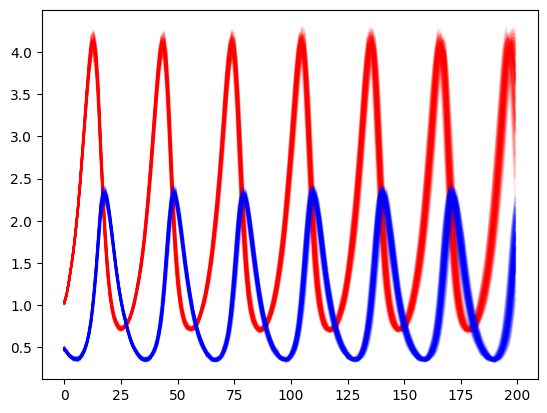

In [26]:
_ = plt.plot(predator.T, color="red", alpha=0.1)
_ = plt.plot(prey.T, color="blue", alpha=0.1)

In [27]:
likelihood_condtion_mask = jnp.array([0, 1,0,1] + [0] *2 * eval_num_timepoints, dtype=bool)
theta_star = jnp.array([1.5, 1.5])

In [28]:
samples = model.sample(jrandom.PRNGKey(0), 100, theta_star[:4], num_steps=400, condition_mask=likelihood_condtion_mask)

In [29]:
predator, prey = jnp.split(samples[:, 2:], 2, axis=-1)

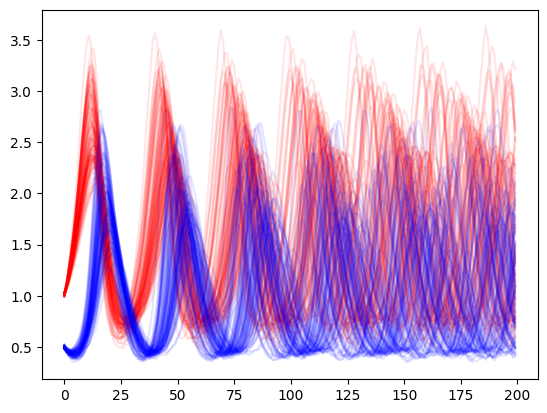

In [30]:
_ = plt.plot(predator.T, color="red", alpha=0.1)
_ = plt.plot(prey.T, color="blue", alpha=0.1)

In [31]:
# posterior
likelihood_condtion_mask = jnp.array([0, 0,0,0] + [1] *2 * eval_num_timepoints, dtype=bool)
xs_o = samples[0, 2:]

In [37]:
with jax.default_device(jax.devices()[2]):
    samples = model.sample(jrandom.PRNGKey(0), 500, xs_o, num_steps=400, condition_mask=likelihood_condtion_mask)

(<Figure size 1000x1000 with 16 Axes>,
 array([[<Axes: xlabel='dim 1'>, <Axes: >, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: xlabel='dim 2'>, <Axes: >, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: xlabel='dim 3'>, <Axes: >],
        [<Axes: >, <Axes: >, <Axes: >, <Axes: xlabel='dim 4'>]],
       dtype=object))

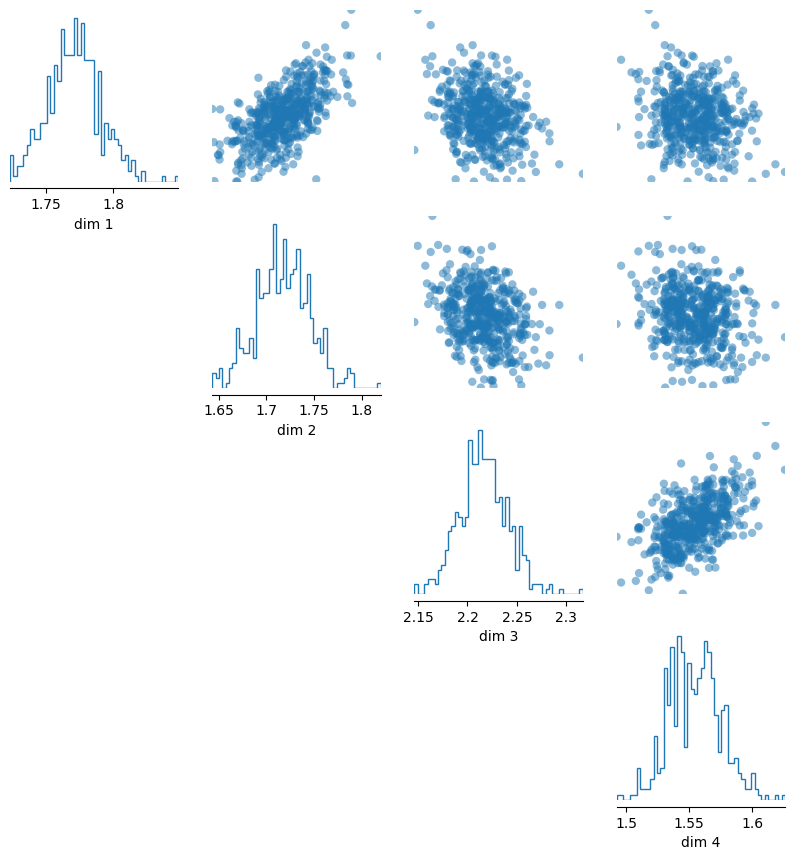

In [39]:
from sbi.analysis import pairplot
import numpy as np

pairplot(np.array(samples), upper="scatter")